# 🕵️ Email/SMS Spam Classifier

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv('spam.csv',encoding="latin-1")

## Load Data

In [4]:
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


## 1. Data Cleaning

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [7]:
# Drop last 3 columns
data.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
data

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [9]:
data.sample(10)

,v1,v2
3592,ham,"Sorry, I'll call later"
4049,ham,Ok ok take care. I can understand.
4448,spam,Urgent UR awarded a complimentary trip to Euro...
2913,spam,Sorry! U can not unsubscribe yet. THE MOB offe...
5260,ham,If anyone calls for a treadmill say you'll buy...
128,ham,HEY GIRL. HOW R U? HOPE U R WELL ME AN DEL R B...
930,ham,I'm really sorry i won't b able 2 do this frid...
2504,ham,"Hello, my boytoy! I made it home and my consta..."
3345,ham,U're welcome... Caught u using broken english ...
3411,ham,No she didnt. I will search online and let you...


In [10]:
# Renaming the columns
data.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [11]:
data

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [12]:
from sklearn.preprocessing import LabelEncoder

In [13]:
encoder = LabelEncoder()
data['target'] = encoder.fit_transform(data['target'])

In [14]:
encoder.classes_

array(['ham', 'spam'], dtype=object)

In [15]:
data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [16]:
data.isnull().sum()

target    0
text      0
dtype: int64

In [17]:
# Check duplicates
data.duplicated().sum()

403

In [18]:
data = data.drop_duplicates(keep = 'first')

In [19]:
data.duplicated().sum()

0

In [20]:
data.shape

(5169, 2)

## 2. EDA

In [21]:
data.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [22]:
data['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

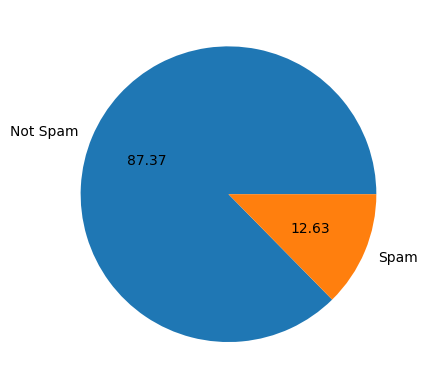

In [23]:
plt.pie(data['target'].value_counts(),labels=['Not Spam','Spam'],autopct="%0.2f")
plt.show()

## Data is imbalenced

In [24]:
# Natural Language Toolkit
import nltk 

In [25]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\piyus\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [26]:
data['num_characters'] = data['text'].apply(len)
data

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [27]:
# Num of words
data['num_words'] = data['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [28]:
# No.of snetences
data['num_Sent'] = data['text'].apply(lambda x: len(nltk.sent_tokenize(x)))

In [29]:
data

,target,text,num_characters,num_words,num_Sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [30]:
data[['num_characters','num_words','num_Sent']].describe()

,num_characters,num_words,num_Sent
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [31]:
data[data['target'] ==0][['num_characters','num_words','num_Sent']].describe()

,num_characters,num_words,num_Sent
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [32]:
data[data['target'] ==1][['num_characters','num_words','num_Sent']].describe()

,num_characters,num_words,num_Sent
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

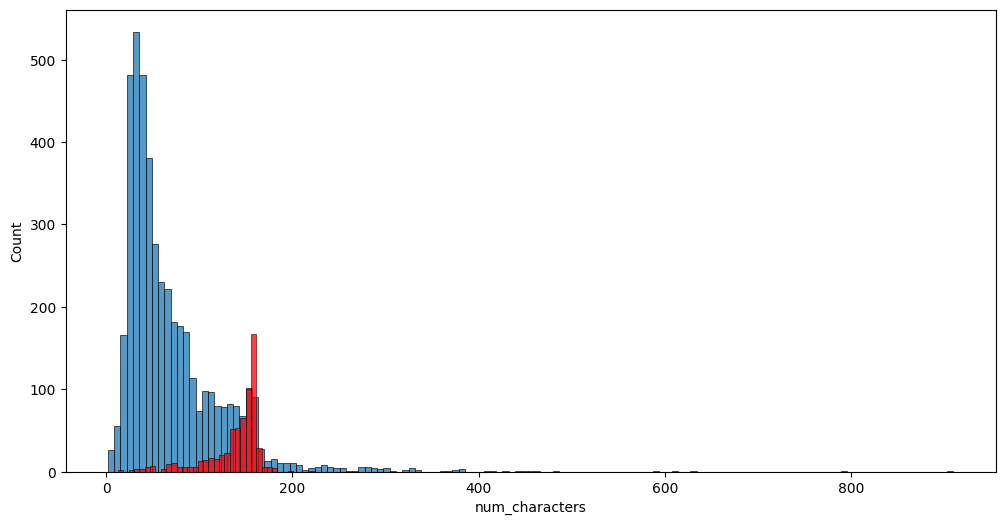

In [33]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['target'] == 0]['num_characters'])
sns.histplot(data[data['target'] == 1]['num_characters'],color='r')

<Axes: xlabel='num_words', ylabel='Count'>

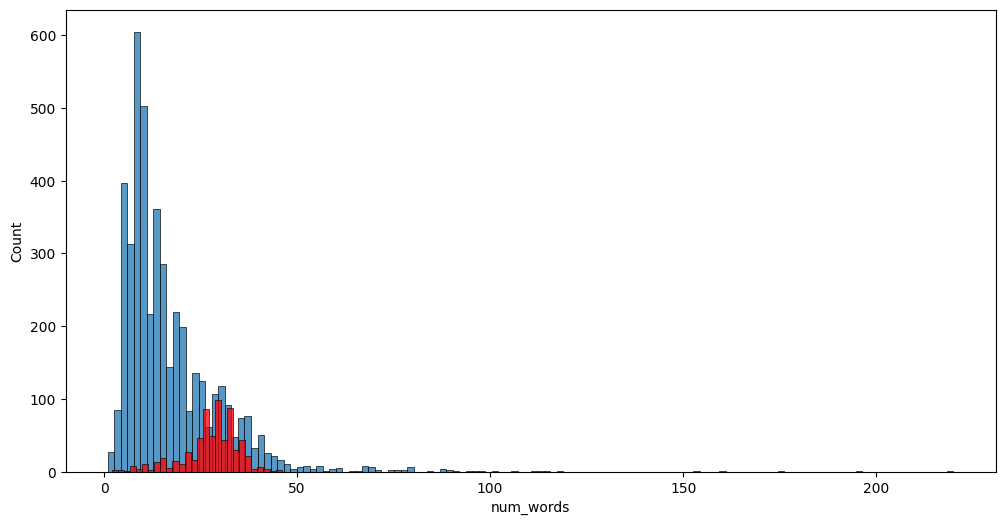

In [34]:
plt.figure(figsize=(12,6))
sns.histplot(data[data['target'] == 0]['num_words'])
sns.histplot(data[data['target'] == 1]['num_words'],color='r')

## Realtion Btw target columns And Other columns

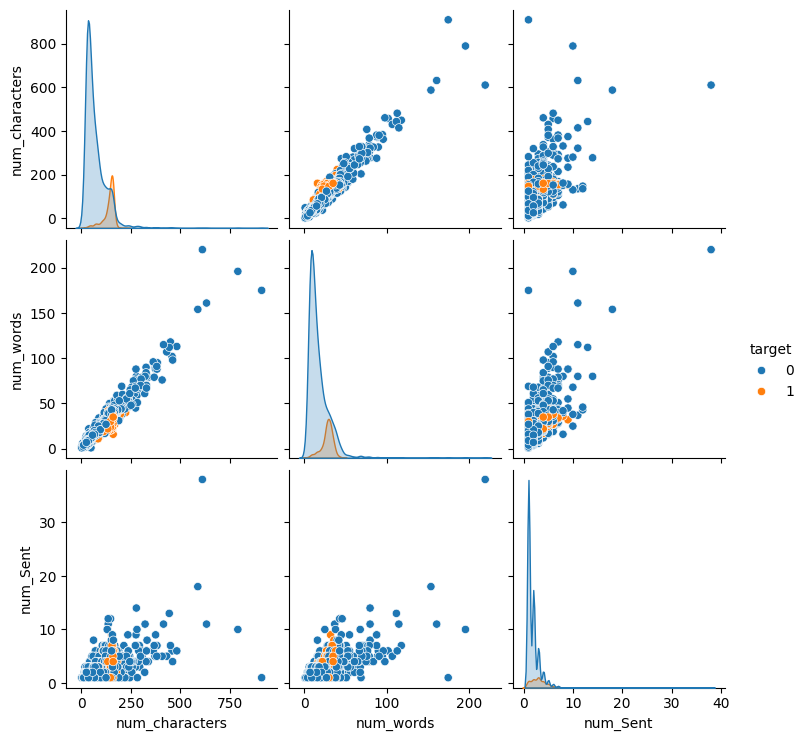

In [35]:
sns.pairplot(data,hue='target')

<Axes: >

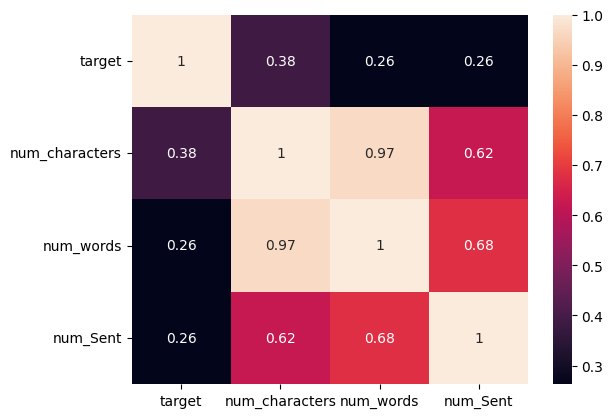

In [36]:
sns.heatmap(data.corr(numeric_only=True),annot=True)

## 3. Data Preprocessing

In [37]:
data

,target,text,num_characters,num_words,num_Sent
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [38]:
# Stopwords are: High-frequency words that often don’t help distinguish between classes.
# Ex:- "You are not selected" , If you remove stopwords: we get only "selected"

# ps = PorterStemmer() comes from NLTK.
# It’s a stemming algorithm
# ps.stem(word):- It reduces a word to its root form (not perfect English root—just a crude base form).


In [39]:
def transformed_text(text):
    import nltk
    from nltk.corpus import stopwords
    from nltk.stem import PorterStemmer
    
    ps = PorterStemmer()
    stop_words = set(stopwords.words('english'))
    
    text = text.lower()  # text into lower case
    words = nltk.word_tokenize(text) # Break the sentence in words in list.
                                     # each word is token.
    y = [] 
    for word in words:
        if word.isalnum() and word not in stop_words:
            y.append(ps.stem(word)) #Ex: running -> run
            # This reduces feature space and improves generalization.
    
    return " ".join(y)

In [40]:
transformed_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [41]:
data['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [42]:
data['transformed_text'] = data['text'].apply(transformed_text)

In [43]:
data

,target,text,num_characters,num_words,num_Sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tri 2 contact u pound prize 2 claim e...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitch act like interest buy someth els nex...


In [44]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [45]:
spam = wc.generate(data[data['target']==1]['transformed_text'].str.cat(sep=" "))

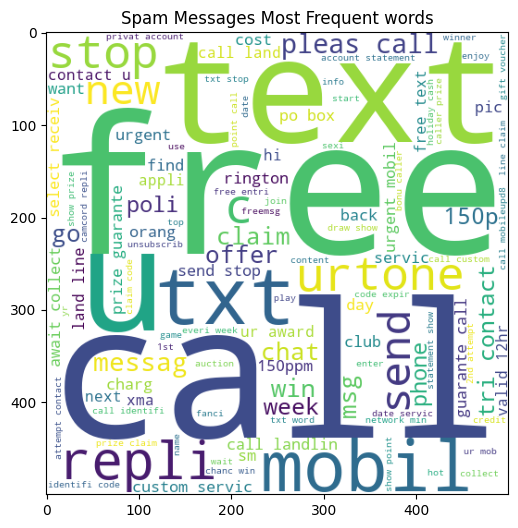

In [46]:
plt.figure(figsize=(12,6))
plt.title('Spam Messages Most Frequent words')
plt.imshow(spam)

In [47]:
not_spam = wc.generate(data[data['target']==0]['transformed_text'].str.cat(sep=" "))

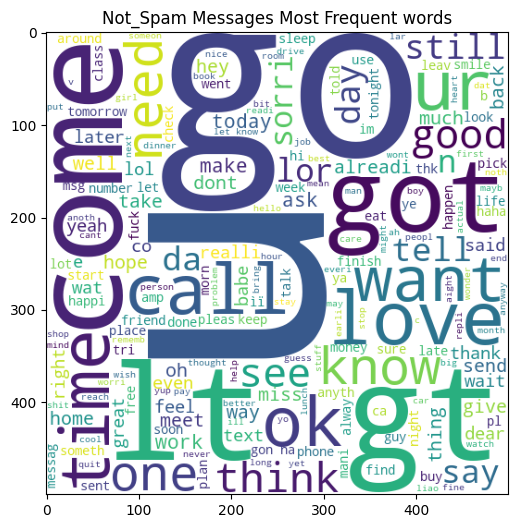

In [48]:
plt.figure(figsize=(12,6))
plt.title('Not_Spam Messages Most Frequent words')
plt.imshow(not_spam)

In [49]:
data.head()

,target,text,num_characters,num_words,num_Sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [50]:
spam_corpus = []
for msg in data[data['target']==1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [51]:
len(spam_corpus)

9939

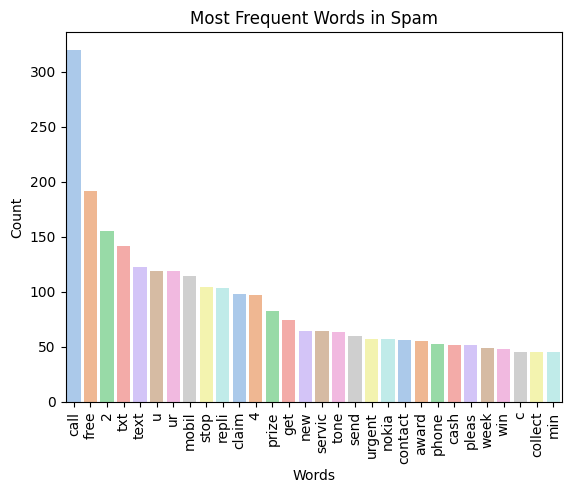

In [52]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(spam_corpus).most_common(30))[1],palette='pastel')
plt.xticks(rotation='vertical')
plt.title('Most Frequent Words in Spam')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

In [53]:
not_spam_corpus = []
for msg in data[data['target']==0]['transformed_text'].tolist():
    for word in msg.split():
        not_spam_corpus.append(word)

In [54]:
len(not_spam_corpus)

35404

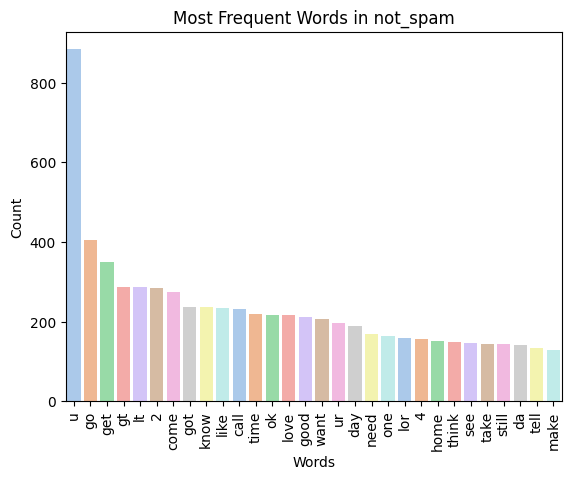

In [55]:
from collections import Counter
sns.barplot(x=pd.DataFrame(Counter(not_spam_corpus).most_common(30))[0],y=pd.DataFrame(Counter(not_spam_corpus).most_common(30))[1],palette='pastel')
plt.xticks(rotation='vertical')
plt.title('Most Frequent Words in not_spam')
plt.xlabel('Words')
plt.ylabel('Count')
plt.show()

## Text Vectorizion

In [56]:
# using bag of words
data.head()

,target,text,num_characters,num_words,num_Sent,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## 4. Model Building

In [83]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(max_features=3000)

In [84]:
X = tfidf.fit_transform(data['transformed_text']).toarray()
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [85]:
y = data['target'].values

In [86]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=32)

In [87]:
X_train.shape, y_train.shape

((4135, 3000), (4135,))

# Navies Bayes Model

In [88]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
from sklearn.model_selection import cross_val_score

In [102]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [103]:
clfs1 = {
    'gnb':gnb,
    'mnb':mnb,
    'bnb':bnb
}

In [107]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    
    return accuracy, precision

In [108]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs1.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  gnb
Accuracy -  0.8636363636363636
Precision -  0.43457943925233644
For  mnb
Accuracy -  0.9835589941972921
Precision -  1.0
For  bnb
Accuracy -  0.9835589941972921
Precision -  0.9897959183673469


## Compare the Models

In [79]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [80]:
svc = SVC(kernel='sigmoid', gamma=1.0)
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [111]:
clfs = {
    'SVC' : svc,
    'NB': mnb, 
    'DT': dtc, 
    'LR': lrc, 
    'RF': rfc, 
    'AdaBoost': abc, 
}

## Model Evaluation

In [112]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():
    
    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)
    
    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9845261121856866
Precision -  0.970873786407767
For  NB
Accuracy -  0.9835589941972921
Precision -  1.0
For  DT
Accuracy -  0.9342359767891683
Precision -  0.7647058823529411
For  LR
Accuracy -  0.9642166344294004
Precision -  0.9042553191489362
For  RF
Accuracy -  0.9748549323017408
Precision -  0.978021978021978
For  AdaBoost
Accuracy -  0.9313346228239845
Precision -  0.8


In [113]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [114]:
performance_df

,Algorithm,Accuracy,Precision
1,NB,0.983559,1.000000
4,RF,0.974855,0.978022
0,SVC,0.984526,0.970874
3,LR,0.964217,0.904255
5,AdaBoost,0.931335,0.800000
2,DT,0.934236,0.764706


In [117]:
print('XGBoosting',train_classifier(xgb,X_train,y_train,X_test,y_test))
print('GradientBoosting',train_classifier(gbdt,X_train,y_train,X_test,y_test))

XGBoosting (0.9709864603481625, 0.9368421052631579)
GradientBoosting (0.9535783365570599, 0.891566265060241)


## Final Model Report 

In [231]:
mnb.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [232]:
y_ped4 = mnb.predict(X_test)

In [233]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_ped4))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       921
           1       1.00      0.86      0.92       113

    accuracy                           0.98      1034
   macro avg       0.99      0.93      0.96      1034
weighted avg       0.98      0.98      0.98      1034



# Pick the model In single Step without manually Preprocessing

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [ ]:
# TfidfVectorizer this import handle all the textual data like stop words, tokenization, PorterStemmer its handles all prepr

In [14]:
nv =  MultinomialNB()

In [23]:
data.shape

(5572, 2)

In [15]:
x1 = data['text']
y1 = data['target']

In [16]:
x_train,x_test,y_train1,y_test1 = train_test_split(x1,y1,test_size=0.2,random_state=32)

In [25]:
x_train.shape,x_test.shape

((4457,), (1115,))

In [299]:
pipe = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=3000, stop_words='english')),
    ('model', MultinomialNB())
])

pipe.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [300]:
y_predict = pipe.predict(x_test)
print('accuracy_score:',accuracy_score(y_test1,y_predict))
print('precision_score:',precision_score(y_test1,y_predict))

accuracy_score: 0.9874274661508704
precision_score: 1.0


In [301]:
print(classification_report(y_test1,y_predict)) # same report 

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       921
           1       1.00      0.88      0.94       113

    accuracy                           0.99      1034
   macro avg       0.99      0.94      0.97      1034
weighted avg       0.99      0.99      0.99      1034



## Model Picking

In [302]:
import pickle
pickle.dump(pipe,open('Pipeline.pkl','wb'))

In [126]:
import sklearn
print(np.__version__)
print(pd.__version__)
print(sklearn.__version__)
print(nltk.__version__)
import streamlit as st
print(st.__version__)

1.26.4
2.3.3
1.8.0
3.9.4
1.56.0


##                                                                        ----Model Is Ready----